# Epidemiological Intelligence — Modelagem Estatística

## Objetivo

Esta etapa tem como objetivo modelar a relação entre variáveis climáticas e ocorrência de casos epidemiológicos.

Serão comparados modelos adequados a diferentes características da variável resposta:

- OLS como baseline estatístico;
- Poisson como baseline para dados de contagem;
- Regressão Binomial Negativa como principal candidata devido à forte sobredispersão observada na EDA.

A modelagem será realizada separadamente por doença, considerando também efeitos de sazonalidade, diferenças entre municípios e variáveis climáticas selecionadas a partir das hipóteses geradas durante a análise exploratória.

A validação será temporal, evitando divisão aleatória dos dados e reduzindo risco de vazamento de informação entre períodos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [2]:
from google.cloud import bigquery

PROJECT_ID = "affable-alpha-506516-r7"

client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT *
FROM `affable-alpha-506516-r7.epidemiological_intelligence.epidemiology_climate_monthly`
ORDER BY reference_date, municipality, disease
"""

df = client.query(query).to_dataframe()

c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [3]:
df.shape

(21384, 19)

In [4]:
df.columns.tolist()

['municipality',
 'year',
 'month',
 'municipality_code',
 'reference_date',
 'cases',
 'source_file',
 'ingestion_timestamp',
 'disease',
 'precipitation_sum_mm',
 'precipitation_avg_observation_mm',
 'precipitation_max_observation_mm',
 'temperature_avg_c',
 'dew_point_avg_c',
 'relative_humidity_avg_pct',
 'atmospheric_pressure_avg_mb',
 'wind_speed_avg_ms',
 'wind_gust_max_ms',
 'station_count']

In [5]:
df["reference_date"] = pd.to_datetime(df["reference_date"])

In [6]:
train_df = df[
    df["reference_date"] < "2024-01-01"
].copy()

test_df = df[
    df["reference_date"] >= "2024-01-01"
].copy()

In [7]:
print(
    "Treino:",
    train_df["reference_date"].min(),
    "→",
    train_df["reference_date"].max()
)

print(
    "Teste:",
    test_df["reference_date"].min(),
    "→",
    test_df["reference_date"].max()
)

print("Treino:", train_df.shape)
print("Teste:", test_df.shape)

Treino: 2015-01-01 00:00:00 → 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 → 2025-12-01 00:00:00
Treino: (17496, 19)
Teste: (3888, 19)


In [8]:
DISEASE = "BRONQUITE AGUDA"

train = train_df[
    train_df["disease"] == DISEASE
].copy()

test = test_df[
    test_df["disease"] == DISEASE
].copy()

In [9]:
print(train.shape)
print(test.shape)

(2916, 19)
(648, 19)


In [10]:
baseline_prediction = train["cases"].mean()

test["baseline_pred"] = baseline_prediction

In [11]:
baseline_mae = mean_absolute_error(
    test["cases"],
    test["baseline_pred"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["cases"],
        test["baseline_pred"]
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 17.14283582279124
Baseline RMSE: 56.360748121901295


In [12]:
ols_simple = smf.ols(
    formula="""
        cases ~ temperature_avg_c
    """,
    data=train
).fit()

print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.585
Date:                Wed, 26 Aug 2026   Prob (F-statistic):            0.00592
Time:                        11:41:03   Log-Likelihood:                -15235.
No. Observations:                2844   AIC:                         3.047e+04
Df Residuals:                    2842   BIC:                         3.049e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            23.0231      4.63

In [13]:
test["ols_simple_pred"] = ols_simple.predict(test)

In [14]:
test["ols_simple_pred"] = ols_simple.predict(test)

ols_eval = test[
    test["cases"].notna()
    & test["ols_simple_pred"].notna()
].copy()

ols_mae = mean_absolute_error(
    ols_eval["cases"],
    ols_eval["ols_simple_pred"]
)

ols_rmse = np.sqrt(
    mean_squared_error(
        ols_eval["cases"],
        ols_eval["ols_simple_pred"]
    )
)

print("Linhas no teste:", len(test))
print("Linhas avaliadas:", len(ols_eval))

print("OLS MAE:", ols_mae)
print("OLS RMSE:", ols_rmse)

print(
    "Previsões negativas:",
    (ols_eval["ols_simple_pred"] < 0).sum()
)

Linhas no teste: 648
Linhas avaliadas: 590
OLS MAE: 17.704263121706674
OLS RMSE: 58.87333790808591
Previsões negativas: 0


In [15]:
baseline_prediction = train["cases"].mean()

ols_eval["baseline_pred"] = baseline_prediction

baseline_mae = mean_absolute_error(
    ols_eval["cases"],
    ols_eval["baseline_pred"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        ols_eval["cases"],
        ols_eval["baseline_pred"]
    )
)

print("Média histórica:", baseline_prediction)
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Média histórica: 10.386488340192043
Baseline MAE: 18.035603682778824
Baseline RMSE: 59.00583403740608


In [16]:
print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  cases   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.585
Date:                Wed, 26 Aug 2026   Prob (F-statistic):            0.00592
Time:                        11:41:03   Log-Likelihood:                -15235.
No. Observations:                2844   AIC:                         3.047e+04
Df Residuals:                    2842   BIC:                         3.049e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            23.0231      4.63

### Baseline e regressão OLS

O primeiro modelo utilizado foi uma regressão linear simples (OLS), considerando a temperatura média mensal como variável explicativa para os casos de bronquite aguda.

No conjunto de teste, o baseline baseado na média histórica apresentou MAE de aproximadamente 18,04 casos e RMSE de 59,01 casos. O modelo OLS apresentou MAE de 17,70 e RMSE de 58,87, representando apenas uma pequena melhoria em relação ao baseline.

O coeficiente estimado para temperatura foi de aproximadamente -0,66, com p-valor de 0,006, indicando uma associação negativa estatisticamente significativa entre temperatura média e número de casos no conjunto de treinamento.

Entretanto, o R² do modelo foi de apenas 0,003, indicando que a temperatura isoladamente explica uma parcela muito pequena da variabilidade observada nos casos.

Além disso, os diagnósticos dos resíduos indicaram forte assimetria e elevada curtose, coerentes com a presença de picos de casos identificados durante a análise exploratória.

Portanto, apesar da associação estatisticamente significativa, o modelo OLS simples apresenta baixo poder explicativo e apenas pequena melhoria preditiva em relação ao baseline. Esse resultado reforça a necessidade de utilizar modelos específicos para dados de contagem e capazes de representar adequadamente a distribuição observada.

In [17]:
poisson_simple = smf.glm(
    formula="cases ~ temperature_avg_c",
    data=train,
    family=sm.families.Poisson()
).fit()

print(poisson_simple.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  cases   No. Observations:                 2844
Model:                            GLM   Df Residuals:                     2842
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -75616.
Date:                Wed, 26 Aug 2026   Deviance:                   1.4617e+05
Time:                        11:41:03   Pearson chi2:                 6.60e+05
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4864
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.5099      0.02

In [18]:
test["poisson_simple_pred"] = poisson_simple.predict(test)

poisson_eval = test[
    test["cases"].notna()
    & test["poisson_simple_pred"].notna()
].copy()

In [19]:
poisson_mae = mean_absolute_error(
    poisson_eval["cases"],
    poisson_eval["poisson_simple_pred"]
)

poisson_rmse = np.sqrt(
    mean_squared_error(
        poisson_eval["cases"],
        poisson_eval["poisson_simple_pred"]
    )
)

print("Poisson MAE:", poisson_mae)
print("Poisson RMSE:", poisson_rmse)

print(
    "Previsão mínima:",
    poisson_eval["poisson_simple_pred"].min()
)

Poisson MAE: 17.73584582289514
Poisson RMSE: 58.8896115844294
Previsão mínima: 5.411978439108845


In [20]:
dispersion = (
    poisson_simple.pearson_chi2
    / poisson_simple.df_resid
)

print("Dispersão:", dispersion)

Dispersão: 232.12834245440484


### Regressão de Poisson

Como a variável resposta representa uma contagem de casos, foi ajustado um modelo de regressão de Poisson utilizando inicialmente a temperatura média mensal como variável explicativa, mantendo a mesma especificação utilizada no modelo OLS para permitir uma comparação direta.

O modelo apresentou MAE de aproximadamente 17,74 e RMSE de 58,89, resultados muito próximos aos obtidos pela regressão OLS e apenas ligeiramente superiores ao baseline.

Embora a regressão de Poisson seja conceitualmente mais apropriada para dados de contagem e produza apenas valores esperados não negativos, foi identificada forte sobredispersão. A razão entre o qui-quadrado de Pearson e os graus de liberdade foi aproximadamente 232,13, muito superior ao valor próximo de 1 esperado sob uma especificação Poisson adequada.

Esse resultado é consistente com a análise exploratória, que mostrou variância substancialmente superior à média para os casos de bronquite aguda.

Dessa forma, a hipótese de equidispersão da distribuição de Poisson não é compatível com os dados observados, justificando a utilização de um modelo capaz de acomodar sobredispersão, como a regressão Binomial Negativa.

In [21]:
nb_simple = smf.glm(
    formula="cases ~ temperature_avg_c",
    data=train,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_simple.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  cases   No. Observations:                 2844
Model:                            GLM   Df Residuals:                     2842
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9573.8
Date:                Wed, 26 Aug 2026   Deviance:                       11263.
Time:                        11:41:03   Pearson chi2:                 5.46e+04
No. Iterations:                    11   Pseudo R-squ. (CS):            0.06884
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.7647      0.09

c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [22]:
test["nb_simple_pred"] = nb_simple.predict(test)

nb_eval = test[
    test["cases"].notna()
    & test["nb_simple_pred"].notna()
].copy()

nb_mae = mean_absolute_error(
    nb_eval["cases"],
    nb_eval["nb_simple_pred"]
)

nb_rmse = np.sqrt(
    mean_squared_error(
        nb_eval["cases"],
        nb_eval["nb_simple_pred"]
    )
)

print("Negative Binomial MAE:", nb_mae)
print("Negative Binomial RMSE:", nb_rmse)
print("Previsão mínima:", nb_eval["nb_simple_pred"].min())

Negative Binomial MAE: 17.744338797979356
Negative Binomial RMSE: 58.88530372944297
Previsão mínima: 4.666664669284369


In [23]:
import statsmodels.formula.api as smf

nb_estimated = smf.negativebinomial(
    formula="cases ~ temperature_avg_c",
    data=train
).fit()

print(nb_estimated.summary())

Optimization terminated successfully.
         Current function value: 2.422210
         Iterations: 18
         Function evaluations: 29
         Gradient evaluations: 29
                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2844
Model:               NegativeBinomial   Df Residuals:                     2842
Method:                           MLE   Df Model:                            1
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                0.002637
Time:                        11:41:03   Log-Likelihood:                -6888.8
converged:                       True   LL-Null:                       -6907.0
Covariance Type:            nonrobust   LLR p-value:                 1.579e-09
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             3.

In [24]:
test["nb_estimated_pred"] = nb_estimated.predict(test)

nb_estimated_eval = test[
    test["cases"].notna()
    & test["nb_estimated_pred"].notna()
].copy()

nb_estimated_mae = mean_absolute_error(
    nb_estimated_eval["cases"],
    nb_estimated_eval["nb_estimated_pred"]
)

nb_estimated_rmse = np.sqrt(
    mean_squared_error(
        nb_estimated_eval["cases"],
        nb_estimated_eval["nb_estimated_pred"]
    )
)

print("NB estimada MAE:", nb_estimated_mae)
print("NB estimada RMSE:", nb_estimated_rmse)
print(
    "Previsão mínima:",
    nb_estimated_eval["nb_estimated_pred"].min()
)

NB estimada MAE: 17.74647971340571
NB estimada RMSE: 58.88532125103573
Previsão mínima: 4.620413853893764


In [25]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error

municipality_results = []

for municipality in df["municipality"].dropna().unique():

    muni_train = train[
        train["municipality"] == municipality
    ].dropna(subset=["cases", "temperature_avg_c"]).copy()

    muni_test = test[
        test["municipality"] == municipality
    ].dropna(subset=["cases", "temperature_avg_c"]).copy()

    # Evita municípios com poucos dados
    if len(muni_train) < 30 or len(muni_test) == 0:
        continue

    try:
        model = smf.negativebinomial(
            formula="cases ~ temperature_avg_c",
            data=muni_train
        ).fit(disp=False)

        muni_test["prediction"] = model.predict(muni_test)

        mae = mean_absolute_error(
            muni_test["cases"],
            muni_test["prediction"]
        )

        rmse = np.sqrt(
            mean_squared_error(
                muni_test["cases"],
                muni_test["prediction"]
            )
        )

        municipality_results.append({
            "municipality": municipality,
            "train_n": len(muni_train),
            "test_n": len(muni_test),
            "temperature_coef": model.params.get(
                "temperature_avg_c",
                np.nan
            ),
            "temperature_pvalue": model.pvalues.get(
                "temperature_avg_c",
                np.nan
            ),
            "alpha": model.params.get("alpha", np.nan),
            "mae": mae,
            "rmse": rmse
        })

    except Exception as e:
        print(f"Erro em {municipality}: {e}")

municipality_results = pd.DataFrame(municipality_results)

municipality_results.sort_values(
    "mae"
)

c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


,municipality,train_n,test_n,temperature_coef,temperature_pvalue,alpha,mae,rmse
4,CAMBARA DO SUL,84,24,-0.353874,2.304587e-02,0.402232,0.096077,0.144325
22,TEUTONIA,108,19,-0.206555,NaN,0.000005,0.116786,0.156633
2,CACAPAVA DO SUL,108,24,-0.093335,2.422156e-01,5.619212,0.358185,0.772442
23,TORRES,106,3,-0.192274,8.306860e-09,0.568562,0.559289,0.609087
18,SANTIAGO,106,24,-0.164824,2.607435e-03,1.508319,0.569670,0.959544
3,CAMAQUA,108,23,-0.153558,1.872750e-04,0.549300,0.668600,0.821343
15,RIO PARDO,106,24,-0.177891,1.090259e-06,0.381447,0.755654,1.018646
6,CANELA,108,21,-0.084557,5.053510e-02,1.249725,0.814538,1.001880
10,LAGOA VERMELHA,107,24,-0.186546,3.906247e-03,1.636701,0.824047,1.503643
19,SANTO AUGUSTO,105,24,-0.145180,6.178160e-02,3.837676,1.219968,1.889680


In [26]:
comparison = []

for municipality in municipality_results["municipality"]:

    muni_train = train[
        train["municipality"] == municipality
    ].dropna(subset=["cases"])

    muni_test = test[
        test["municipality"] == municipality
    ].dropna(subset=["cases", "temperature_avg_c"])

    if len(muni_test) == 0:
        continue

    # média histórica do município
    historical_mean = muni_train["cases"].mean()

    # baseline
    baseline_pred = np.repeat(
        historical_mean,
        len(muni_test)
    )

    baseline_mae = mean_absolute_error(
        muni_test["cases"],
        baseline_pred
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            muni_test["cases"],
            baseline_pred
        )
    )

    # pega resultados NB
    row = municipality_results[
        municipality_results["municipality"] == municipality
    ].iloc[0]

    # ganho percentual sobre baseline
    mae_improvement = (
        (baseline_mae - row["mae"])
        / baseline_mae * 100
        if baseline_mae != 0 else np.nan
    )

    comparison.append({
        "municipality": municipality,
        "mean_cases_test": muni_test["cases"].mean(),

        "baseline_mae": baseline_mae,
        "nb_mae": row["mae"],

        "baseline_rmse": baseline_rmse,
        "nb_rmse": row["rmse"],

        "mae_improvement_pct": mae_improvement,

        "temperature_coef": row["temperature_coef"],
        "temperature_pvalue": row["temperature_pvalue"],
        "alpha": row["alpha"]
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(
    "mae_improvement_pct",
    ascending=False
)

,municipality,mean_cases_test,baseline_mae,nb_mae,baseline_rmse,nb_rmse,mae_improvement_pct,temperature_coef,temperature_pvalue,alpha
23,TORRES,1.666667,1.064815,0.559289,1.354291,0.609087,47.475474,-0.192274,8.306860e-09,0.568562
13,PORTO ALEGRE,258.583333,132.633488,80.057073,155.051573,107.393348,39.640377,-0.163554,1.043575e-24,0.353582
17,SANTA ROSA,9.384615,7.029915,4.437729,8.311807,6.411796,36.873645,-0.129112,1.364093e-09,0.475618
12,PASSO FUNDO,8.000000,5.722994,3.852999,8.071637,5.743177,32.675118,-0.186847,9.988869e-14,0.527447
16,SANTA MARIA,9.291667,6.628858,4.534486,9.684415,6.505508,31.594760,-0.182699,3.827948e-10,0.977722
0,BAGE,8.833333,5.756944,4.000867,8.691071,5.868619,30.503637,-0.191263,2.760674e-15,0.584922
14,RIO GRANDE,10.583333,8.043210,5.957166,10.796677,8.165715,25.935460,-0.131964,2.818558e-09,0.595179
22,TEUTONIA,0.000000,0.157407,0.116786,0.157407,0.156633,25.806731,-0.206555,NaN,0.000005
20,SAO BORJA,6.416667,4.418210,3.341792,5.877486,4.501543,24.363212,-0.132489,8.051932e-05,1.787677
15,RIO PARDO,0.875000,0.933642,0.755654,1.280124,1.018646,19.063817,-0.177891,1.090259e-06,0.381447


## Controle por município e sazonalidade

Os tipos das colunas são normalizados antes do uso com `patsy/statsmodels`, evitando o erro `Cannot interpret 'Int64Dtype()' as a data type`.


In [27]:
model_data_train = train.dropna(
    subset=["cases", "temperature_avg_c", "municipality", "month"]
).copy()

model_data_test = test.dropna(
    subset=["cases", "temperature_avg_c", "municipality", "month"]
).copy()

for dataset in [model_data_train, model_data_test]:
    dataset["cases"] = dataset["cases"].astype("float64")
    dataset["temperature_avg_c"] = dataset["temperature_avg_c"].astype("float64")
    dataset["month"] = dataset["month"].astype("int64")
    dataset["municipality"] = dataset["municipality"].astype(str)

print(
    model_data_train[
        ["cases", "temperature_avg_c", "municipality", "month"]
    ].dtypes
)


cases                float64
temperature_avg_c    float64
municipality             str
month                  int64
dtype: object


In [28]:
nb_seasonality_only = smf.negativebinomial(
    formula="cases ~ C(municipality) + C(month)",
    data=model_data_train
).fit(method="bfgs", maxiter=500, disp=False)

nb_fixed_effects = smf.negativebinomial(
    formula="cases ~ temperature_avg_c + C(municipality) + C(month)",
    data=model_data_train
).fit(method="bfgs", maxiter=500, disp=False)

print("Município + mês convergiu:", nb_seasonality_only.mle_retvals.get("converged", False))
print("Município + mês + temperatura convergiu:", nb_fixed_effects.mle_retvals.get("converged", False))


Município + mês convergiu: True
Município + mês + temperatura convergiu: True


In [29]:
model_data_test["seasonality_pred"] = nb_seasonality_only.predict(model_data_test)
model_data_test["nb_fixed_pred"] = nb_fixed_effects.predict(model_data_test)

seasonality_mae = mean_absolute_error(model_data_test["cases"], model_data_test["seasonality_pred"])
seasonality_rmse = np.sqrt(mean_squared_error(model_data_test["cases"], model_data_test["seasonality_pred"]))

fixed_mae = mean_absolute_error(model_data_test["cases"], model_data_test["nb_fixed_pred"])
fixed_rmse = np.sqrt(mean_squared_error(model_data_test["cases"], model_data_test["nb_fixed_pred"]))

print("Município + mês")
print("MAE:", seasonality_mae)
print("RMSE:", seasonality_rmse)

print("\nMunicípio + mês + temperatura")
print("MAE:", fixed_mae)
print("RMSE:", fixed_rmse)

print("\nAlpha:", nb_fixed_effects.params["alpha"])
print("Coef temperatura:", nb_fixed_effects.params["temperature_avg_c"])
print("p-value temperatura:", nb_fixed_effects.pvalues["temperature_avg_c"])


Município + mês
MAE: 4.920579848803297
RMSE: 17.570802189170415

Município + mês + temperatura
MAE: 4.997749602302522
RMSE: 17.688095414451613

Alpha: 0.7682213023690515
Coef temperatura: 0.023795523456632623
p-value temperatura: 0.1515860845145515


## Contribuição individual das variáveis climáticas

Cada variável é comparada contra um baseline `município + mês`, sempre usando exatamente as mesmas linhas válidas da variável testada.


In [30]:
climate_vars = [
    "temperature_avg_c",
    "dew_point_avg_c",
    "relative_humidity_avg_pct",
    "atmospheric_pressure_avg_mb",
    "wind_speed_avg_ms",
    "wind_gust_max_ms",
    "precipitation_sum_mm",
    "precipitation_max_observation_mm"
]

results = []

for variable in climate_vars:
    required_cols = ["cases", "municipality", "month", variable]

    train_var = (
        train_df[train_df["disease"] == DISEASE]
        .dropna(subset=required_cols)
        .copy()
    )
    test_var = (
        test_df[test_df["disease"] == DISEASE]
        .dropna(subset=required_cols)
        .copy()
    )

    if len(train_var) == 0 or len(test_var) == 0:
        continue

    for dataset in [train_var, test_var]:
        dataset["cases"] = dataset["cases"].astype("float64")
        dataset["month"] = dataset["month"].astype("int64")
        dataset["municipality"] = dataset["municipality"].astype(str)
        dataset[variable] = dataset[variable].astype("float64")

    try:
        base_model = smf.negativebinomial(
            formula="cases ~ C(municipality) + C(month)",
            data=train_var
        ).fit(method="bfgs", maxiter=500, disp=False)

        climate_model = smf.negativebinomial(
            formula=f"cases ~ C(municipality) + C(month) + {variable}",
            data=train_var
        ).fit(method="bfgs", maxiter=500, disp=False)

        base_pred = base_model.predict(test_var)
        climate_pred = climate_model.predict(test_var)

        base_mae = mean_absolute_error(test_var["cases"], base_pred)
        mae = mean_absolute_error(test_var["cases"], climate_pred)
        base_rmse = np.sqrt(mean_squared_error(test_var["cases"], base_pred))
        rmse = np.sqrt(mean_squared_error(test_var["cases"], climate_pred))

        results.append({
            "variable": variable,
            "train_n": len(train_var),
            "test_n": len(test_var),
            "coef": climate_model.params.get(variable, np.nan),
            "pvalue": climate_model.pvalues.get(variable, np.nan),
            "alpha": climate_model.params.get("alpha", np.nan),
            "base_mae": base_mae,
            "mae": mae,
            "mae_improvement_pct": (base_mae - mae) / base_mae * 100,
            "base_rmse": base_rmse,
            "rmse": rmse,
            "rmse_improvement_pct": (base_rmse - rmse) / base_rmse * 100,
            "base_converged": base_model.mle_retvals.get("converged", False),
            "converged": climate_model.mle_retvals.get("converged", False)
        })

    except Exception as e:
        print(f"Erro em {variable}: {e}")

climate_comparison = (
    pd.DataFrame(results)
    .sort_values("mae_improvement_pct", ascending=False)
    .reset_index(drop=True)
)

display(climate_comparison)


c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


,variable,train_n,test_n,coef,pvalue,alpha,base_mae,mae,mae_improvement_pct,base_rmse,rmse,rmse_improvement_pct,base_converged,converged
0,relative_humidity_avg_pct,2799,590,0.009986,0.013174,0.762291,4.916649,4.894328,0.453990,17.586319,17.556232,0.171082,True,True
1,precipitation_sum_mm,2757,580,0.000032,0.907714,0.774424,4.950413,4.944939,0.110570,17.598853,17.527986,0.402682,True,True
2,wind_speed_avg_ms,2773,575,0.017723,0.650578,0.759112,4.803291,4.803984,-0.014430,17.726686,17.719930,0.038116,True,True
3,wind_gust_max_ms,2771,575,-0.003679,0.487939,0.758575,4.805502,4.826685,-0.440798,17.749939,17.969043,-1.234390,True,True
4,precipitation_max_observation_mm,2757,580,0.001867,0.474007,0.774119,4.950413,4.978843,-0.574306,17.598853,17.632786,-0.192811,True,True
5,atmospheric_pressure_avg_mb,2837,590,-0.012976,0.452633,0.771265,4.929309,5.004564,-1.526692,17.606882,17.853731,-1.402006,True,True
6,temperature_avg_c,2844,590,0.023796,0.151586,0.768221,4.920580,4.997750,-1.568306,17.570802,17.688095,-0.667546,True,True
7,dew_point_avg_c,2798,590,0.042334,0.001747,0.760509,4.915558,5.019413,-2.112786,17.581451,17.759785,-1.014327,True,True


## Lags climáticos

Os lags são construídos em uma tabela com uma única linha por município e mês. Isso evita deslocar entre doenças diferentes registradas na mesma competência mensal.


In [31]:
old_lag_cols = [col for col in df.columns if "_lag" in col]
df = df.drop(columns=old_lag_cols, errors="ignore")

df["reference_date"] = pd.to_datetime(df["reference_date"])

climate_cols = [
    "municipality",
    "reference_date",
    "temperature_avg_c",
    "relative_humidity_avg_pct",
    "precipitation_sum_mm",
    "precipitation_max_observation_mm"
]

climate_conflicts = (
    df[climate_cols]
    .groupby(["municipality", "reference_date"])
    .nunique(dropna=False)
)

conflict_count = (climate_conflicts > 1).any(axis=1).sum()
print("Município/mês com valores climáticos conflitantes:", conflict_count)

if conflict_count != 0:
    raise ValueError("Existem valores climáticos diferentes para o mesmo município/mês.")

climate_monthly = (
    df[climate_cols]
    .drop_duplicates(subset=["municipality", "reference_date"])
    .sort_values(["municipality", "reference_date"])
    .reset_index(drop=True)
)

duplicates = climate_monthly.duplicated(
    subset=["municipality", "reference_date"]
).sum()

print("Duplicatas município/mês:", duplicates)

if duplicates != 0:
    raise ValueError("A tabela climática ainda possui duplicatas município/mês.")


Município/mês com valores climáticos conflitantes: 0
Duplicatas município/mês: 0


In [32]:
lag_variables = [
    "temperature_avg_c",
    "relative_humidity_avg_pct",
    "precipitation_sum_mm",
    "precipitation_max_observation_mm"
]

for variable in lag_variables:
    for lag in [1, 2, 3]:
        climate_monthly[f"{variable}_lag{lag}"] = (
            climate_monthly
            .groupby("municipality")[variable]
            .shift(lag)
        )

check_climate = (
    climate_monthly[
        climate_monthly["municipality"] == "PORTO ALEGRE"
    ][
        [
            "reference_date",
            "temperature_avg_c",
            "temperature_avg_c_lag1",
            "temperature_avg_c_lag2",
            "temperature_avg_c_lag3"
        ]
    ]
    .sort_values("reference_date")
)

display(check_climate.head(12))


,reference_date,temperature_avg_c,temperature_avg_c_lag1,temperature_avg_c_lag2,temperature_avg_c_lag3
1716,2015-01-01,25.451344,NaN,NaN,NaN
1717,2015-02-01,24.657589,25.451344,NaN,NaN
1718,2015-03-01,23.838038,24.657589,25.451344,NaN
1719,2015-04-01,21.052222,23.838038,24.657589,25.451344
1720,2015-05-01,18.313844,21.052222,23.838038,24.657589
1721,2015-06-01,15.567419,18.313844,21.052222,23.838038
1722,2015-07-01,15.573925,15.567419,18.313844,21.052222
1723,2015-08-01,20.317070,15.573925,15.567419,18.313844
1724,2015-09-01,17.169735,20.317070,15.573925,15.567419
1725,2015-10-01,18.522446,17.169735,20.317070,15.573925


In [33]:
check_dates = (
    climate_monthly[["municipality", "reference_date"]]
    .sort_values(["municipality", "reference_date"])
    .copy()
)

check_dates["previous_date"] = (
    check_dates.groupby("municipality")["reference_date"].shift(1)
)

check_dates["month_difference"] = (
    (
        check_dates["reference_date"].dt.year * 12
        + check_dates["reference_date"].dt.month
    )
    -
    (
        check_dates["previous_date"].dt.year * 12
        + check_dates["previous_date"].dt.month
    )
)

date_gaps = check_dates[
    check_dates["previous_date"].notna()
    & (check_dates["month_difference"] != 1)
]

print("Quebras na sequência mensal:", len(date_gaps))
display(date_gaps.head())

if len(date_gaps) != 0:
    raise ValueError("Existem meses ausentes; os lags precisam ser construídos por chave temporal.")


Quebras na sequência mensal: 0


,municipality,reference_date,previous_date,month_difference


In [34]:
lag_cols = [col for col in climate_monthly.columns if "_lag" in col]

df = df.merge(
    climate_monthly[
        ["municipality", "reference_date"] + lag_cols
    ],
    on=["municipality", "reference_date"],
    how="left",
    validate="many_to_one"
)

duplicate_groups = (
    df
    .groupby(["disease", "municipality", "reference_date"])
    .size()
    .gt(1)
    .sum()
)

print("Grupos duplicados após merge:", duplicate_groups)

if duplicate_groups != 0:
    raise ValueError("O merge dos lags criou duplicatas.")

check_lags = (
    df[
        (df["municipality"] == "PORTO ALEGRE")
        & (df["disease"] == DISEASE)
    ][
        [
            "reference_date",
            "cases",
            "temperature_avg_c",
            "temperature_avg_c_lag1",
            "temperature_avg_c_lag2",
            "temperature_avg_c_lag3",
            "precipitation_sum_mm",
            "precipitation_sum_mm_lag1",
            "precipitation_sum_mm_lag2",
            "precipitation_sum_mm_lag3"
        ]
    ]
    .sort_values("reference_date")
)

display(check_lags.head(12))


Grupos duplicados após merge: 0


,reference_date,cases,temperature_avg_c,temperature_avg_c_lag1,temperature_avg_c_lag2,temperature_avg_c_lag3,precipitation_sum_mm,precipitation_sum_mm_lag1,precipitation_sum_mm_lag2,precipitation_sum_mm_lag3
79,2015-01-01,58,25.451344,NaN,NaN,NaN,159.8,NaN,NaN,NaN
241,2015-02-01,58,24.657589,25.451344,NaN,NaN,99.4,159.8,NaN,NaN
403,2015-03-01,105,23.838038,24.657589,25.451344,NaN,54.0,99.4,159.8,NaN
565,2015-04-01,210,21.052222,23.838038,24.657589,25.451344,76.0,54.0,99.4,159.8
727,2015-05-01,397,18.313844,21.052222,23.838038,24.657589,142.4,76.0,54.0,99.4
889,2015-06-01,493,15.567419,18.313844,21.052222,23.838038,172.4,142.4,76.0,54.0
1051,2015-07-01,472,15.573925,15.567419,18.313844,21.052222,313.4,172.4,142.4,76.0
1213,2015-08-01,278,20.317070,15.573925,15.567419,18.313844,111.6,313.4,172.4,142.4
1375,2015-09-01,286,17.169735,20.317070,15.573925,15.567419,186.6,111.6,313.4,172.4
1537,2015-10-01,239,18.522446,17.169735,20.317070,15.573925,312.6,186.6,111.6,313.4


In [35]:
train_df = df[
    df["reference_date"] < pd.Timestamp("2024-01-01")
].copy()

test_df = df[
    df["reference_date"] >= pd.Timestamp("2024-01-01")
].copy()

lag_test_vars = []

for variable in lag_variables:
    lag_test_vars.append(variable)
    for lag in [1, 2, 3]:
        lag_test_vars.append(f"{variable}_lag{lag}")

print("Treino:", train_df["reference_date"].min(), "→", train_df["reference_date"].max())
print("Teste:", test_df["reference_date"].min(), "→", test_df["reference_date"].max())
print("Número de variáveis testadas:", len(lag_test_vars))
print(lag_test_vars)


Treino: 2015-01-01 00:00:00 → 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 → 2025-12-01 00:00:00
Número de variáveis testadas: 16
['temperature_avg_c', 'temperature_avg_c_lag1', 'temperature_avg_c_lag2', 'temperature_avg_c_lag3', 'relative_humidity_avg_pct', 'relative_humidity_avg_pct_lag1', 'relative_humidity_avg_pct_lag2', 'relative_humidity_avg_pct_lag3', 'precipitation_sum_mm', 'precipitation_sum_mm_lag1', 'precipitation_sum_mm_lag2', 'precipitation_sum_mm_lag3', 'precipitation_max_observation_mm', 'precipitation_max_observation_mm_lag1', 'precipitation_max_observation_mm_lag2', 'precipitation_max_observation_mm_lag3']


In [36]:
lag_results = []

for variable in lag_test_vars:
    required_cols = ["cases", "municipality", "month", variable]

    train_var = (
        train_df[train_df["disease"] == DISEASE]
        .dropna(subset=required_cols)
        .copy()
    )
    test_var = (
        test_df[test_df["disease"] == DISEASE]
        .dropna(subset=required_cols)
        .copy()
    )

    if len(train_var) == 0 or len(test_var) == 0:
        continue

    for dataset in [train_var, test_var]:
        dataset["cases"] = dataset["cases"].astype("float64")
        dataset["month"] = dataset["month"].astype("int64")
        dataset["municipality"] = dataset["municipality"].astype(str)
        dataset[variable] = dataset[variable].astype("float64")

    try:
        base_model = smf.negativebinomial(
            formula="cases ~ C(municipality) + C(month)",
            data=train_var
        ).fit(method="bfgs", maxiter=500, disp=False)

        climate_model = smf.negativebinomial(
            formula=f"cases ~ C(municipality) + C(month) + {variable}",
            data=train_var
        ).fit(method="bfgs", maxiter=500, disp=False)

        base_pred = base_model.predict(test_var)
        climate_pred = climate_model.predict(test_var)

        base_mae = mean_absolute_error(test_var["cases"], base_pred)
        mae = mean_absolute_error(test_var["cases"], climate_pred)
        base_rmse = np.sqrt(mean_squared_error(test_var["cases"], base_pred))
        rmse = np.sqrt(mean_squared_error(test_var["cases"], climate_pred))

        lag_results.append({
            "variable": variable,
            "train_n": len(train_var),
            "test_n": len(test_var),
            "coef": climate_model.params.get(variable, np.nan),
            "pvalue": climate_model.pvalues.get(variable, np.nan),
            "alpha": climate_model.params.get("alpha", np.nan),
            "base_mae": base_mae,
            "mae": mae,
            "mae_improvement_pct": (base_mae - mae) / base_mae * 100,
            "base_rmse": base_rmse,
            "rmse": rmse,
            "rmse_improvement_pct": (base_rmse - rmse) / base_rmse * 100,
            "base_converged": base_model.mle_retvals.get("converged", False),
            "converged": climate_model.mle_retvals.get("converged", False)
        })

    except Exception as e:
        print(f"Erro em {variable}: {e}")

lag_comparison = (
    pd.DataFrame(lag_results)
    .sort_values("mae_improvement_pct", ascending=False)
    .reset_index(drop=True)
)

display(
    lag_comparison[
        [
            "variable",
            "train_n",
            "test_n",
            "coef",
            "pvalue",
            "mae_improvement_pct",
            "rmse_improvement_pct",
            "alpha",
            "base_converged",
            "converged"
        ]
    ].round(4)
)


c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\eduar\Deskt

,variable,train_n,test_n,coef,pvalue,mae_improvement_pct,rmse_improvement_pct,alpha,base_converged,converged
0,precipitation_sum_mm_lag2,2704,588,-0.0004,0.1277,3.2269,5.0681,0.7730,True,True
1,temperature_avg_c_lag1,2817,593,-0.0320,0.0509,0.5751,0.7079,0.7696,True,True
2,precipitation_max_observation_mm_lag2,2704,588,-0.0012,0.6339,0.5016,1.2130,0.7751,True,True
3,relative_humidity_avg_pct,2799,590,0.0100,0.0132,0.4540,0.1711,0.7623,True,True
4,precipitation_max_observation_mm_lag1,2730,584,-0.0013,0.6166,0.4150,0.6659,0.7747,True,True
5,precipitation_sum_mm_lag1,2730,584,-0.0002,0.5104,0.3463,0.4048,0.7744,True,True
6,relative_humidity_avg_pct_lag1,2772,593,0.0094,0.0175,0.1405,0.6781,0.7693,True,True
7,precipitation_sum_mm,2757,580,0.0000,0.9077,0.1106,0.4027,0.7744,True,True
8,precipitation_max_observation_mm_lag3,2677,592,-0.0004,0.8761,-0.0060,-0.1242,0.7727,True,True
9,relative_humidity_avg_pct_lag3,2719,600,-0.0028,0.4881,-0.1131,0.2974,0.7794,True,True


### Avaliação das defasagens climáticas

Após controlar as diferenças estruturais entre municípios e a sazonalidade mensal, foram avaliadas variáveis climáticas contemporâneas e com defasagens de um a três meses.

A precipitação acumulada com defasagem de dois meses apresentou o maior ganho preditivo, reduzindo o MAE em aproximadamente 3,23% e o RMSE em 5,07% em relação ao modelo contendo apenas município e mês. Entretanto, seu coeficiente não apresentou significância estatística ao nível de 5% (p ≈ 0,128), indicando que o resultado deve ser interpretado principalmente sob a perspectiva preditiva.

A temperatura com defasagem de um mês apresentou pequena melhora nas métricas e p-valor próximo ao limite de 5% (p ≈ 0,051). A umidade relativa contemporânea e com defasagem de um mês apresentou associação estatisticamente significativa, embora seus ganhos preditivos tenham sido modestos.

Também foi observado que significância estatística não implica necessariamente melhor capacidade de generalização. A precipitação acumulada com defasagem de três meses apresentou p-valor de aproximadamente 0,002, porém piorou tanto o MAE quanto o RMSE no conjunto de teste.

Esses resultados reforçam a necessidade de avaliar conjuntamente desempenho fora da amostra, significância estatística e plausibilidade epidemiológica na seleção das variáveis.

In [37]:
final_features = [
    "precipitation_sum_mm_lag2",
    "relative_humidity_avg_pct",
    "temperature_avg_c_lag1"
]

required_cols = [
    "cases",
    "municipality",
    "month"
] + final_features

final_train = (
    train_df[
        train_df["disease"] == DISEASE
    ]
    .dropna(subset=required_cols)
    .copy()
)

final_test = (
    test_df[
        test_df["disease"] == DISEASE
    ]
    .dropna(subset=required_cols)
    .copy()
)

for dataset in [final_train, final_test]:
    dataset["cases"] = dataset["cases"].astype("float64")
    dataset["month"] = dataset["month"].astype("int64")
    dataset["municipality"] = dataset["municipality"].astype(str)

    for variable in final_features:
        dataset[variable] = dataset[variable].astype("float64")

In [38]:
final_base = smf.negativebinomial(
    formula="""
        cases ~
        C(municipality) +
        C(month)
    """,
    data=final_train
).fit(
    method="bfgs",
    maxiter=500,
    disp=False
)

In [39]:
final_nb = smf.negativebinomial(
    formula="""
        cases ~
        C(municipality) +
        C(month) +
        precipitation_sum_mm_lag2 +
        relative_humidity_avg_pct +
        temperature_avg_c_lag1
    """,
    data=final_train
).fit(
    method="bfgs",
    maxiter=500,
    disp=False
)

print(final_nb.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                 2608
Model:               NegativeBinomial   Df Residuals:                     2567
Method:                           MLE   Df Model:                           40
Date:                Wed, 26 Aug 2026   Pseudo R-squ.:                  0.2541
Time:                        11:43:01   Log-Likelihood:                -4780.5
converged:                       True   LL-Null:                       -6408.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   0.3634      0.547      0.664      0.507      -0.710       1.436
C(municipality)[T.BENTO GONCALVES]         -

In [40]:
base_pred = final_base.predict(final_test)
final_pred = final_nb.predict(final_test)

base_mae = mean_absolute_error(
    final_test["cases"],
    base_pred
)

final_mae = mean_absolute_error(
    final_test["cases"],
    final_pred
)

base_rmse = np.sqrt(
    mean_squared_error(
        final_test["cases"],
        base_pred
    )
)

final_rmse = np.sqrt(
    mean_squared_error(
        final_test["cases"],
        final_pred
    )
)

print("BASE")
print("MAE:", base_mae)
print("RMSE:", base_rmse)

print("\nMULTIVARIADO")
print("MAE:", final_mae)
print("RMSE:", final_rmse)

print(
    "\nMelhora MAE:",
    round((base_mae - final_mae) / base_mae * 100, 2),
    "%"
)

print(
    "Melhora RMSE:",
    round((base_rmse - final_rmse) / base_rmse * 100, 2),
    "%"
)

print(
    "\nConvergiu:",
    final_nb.mle_retvals.get("converged", False)
)

BASE
MAE: 5.050540966732433
RMSE: 18.0150185276261

MULTIVARIADO
MAE: 4.848530891002762
RMSE: 17.077172806266788

Melhora MAE: 4.0 %
Melhora RMSE: 5.21 %

Convergiu: True


### Modelo multivariado climático

Foi ajustado um modelo Binomial Negativo multivariado contendo efeitos de município e mês, além das variáveis climáticas selecionadas nas análises anteriores: precipitação acumulada com defasagem de dois meses, umidade relativa contemporânea e temperatura média com defasagem de um mês.

Em comparação ao modelo-base contendo apenas município e mês, o modelo climático apresentou redução do MAE de 5,05 para 4,85, correspondendo a uma melhora de aproximadamente 4,0%. O RMSE foi reduzido de 18,02 para 17,08, representando melhora de aproximadamente 5,21%.

O modelo convergiu adequadamente. Os resultados indicam que as variáveis climáticas adicionam capacidade preditiva além das diferenças estruturais entre municípios e da sazonalidade mensal, embora a magnitude do ganho seja moderada.

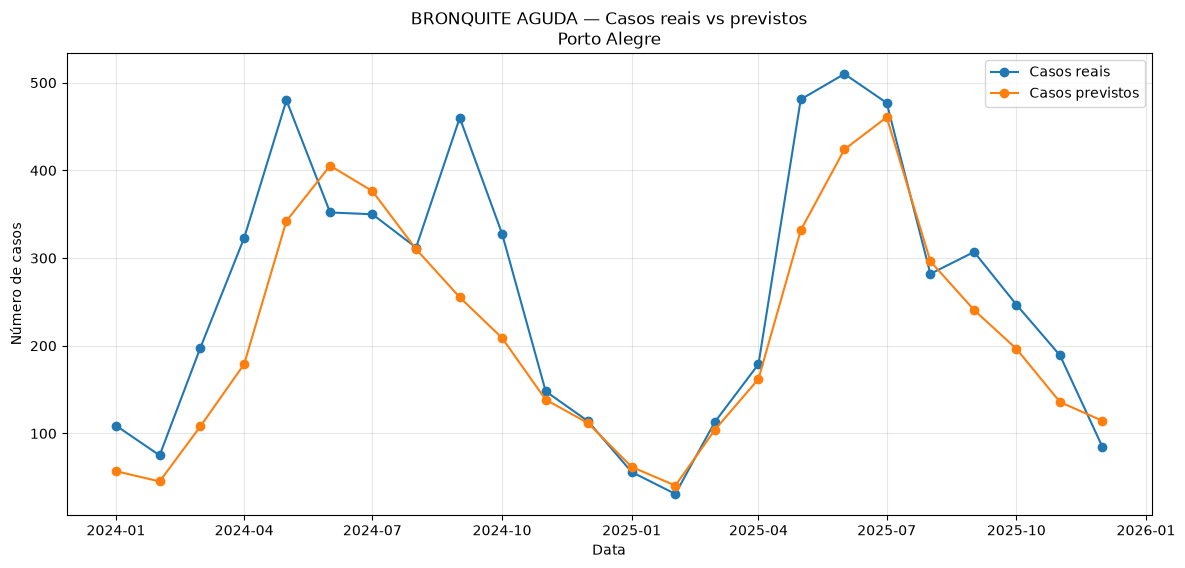

In [41]:
plot_df = final_test[
    final_test["municipality"] == "PORTO ALEGRE"
].copy()

plot_df["prediction"] = final_nb.predict(plot_df)

plot_df = plot_df.sort_values("reference_date")

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["reference_date"],
    plot_df["cases"],
    marker="o",
    label="Casos reais"
)

plt.plot(
    plot_df["reference_date"],
    plot_df["prediction"],
    marker="o",
    label="Casos previstos"
)

plt.title(
    f"{DISEASE} — Casos reais vs previstos\nPorto Alegre"
)

plt.xlabel("Data")
plt.ylabel("Número de casos")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

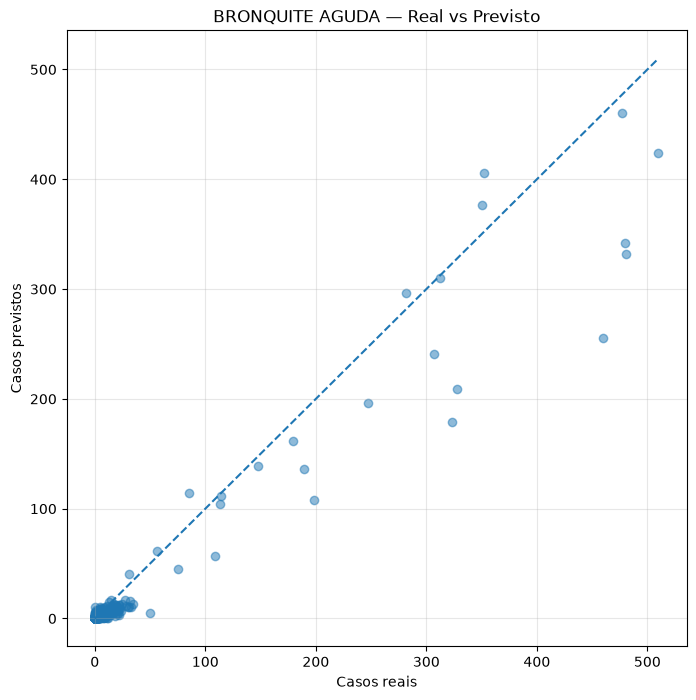

In [42]:
plt.figure(figsize=(8, 8))

plt.scatter(
    final_test["cases"],
    final_pred,
    alpha=0.5
)

max_value = max(
    final_test["cases"].max(),
    final_pred.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Casos reais")
plt.ylabel("Casos previstos")

plt.title(
    f"{DISEASE} — Real vs Previsto"
)

plt.grid(alpha=0.3)

plt.show()

In [43]:
from sklearn.metrics import r2_score

r2 = r2_score(
    final_test["cases"],
    final_pred
)

print("R² teste:", r2)

R² teste: 0.9194123073166334


In [44]:
evaluation = final_test[
    [
        "municipality",
        "reference_date",
        "cases"
    ]
].copy()

evaluation["prediction"] = final_pred

municipality_metrics = (
    evaluation
    .groupby("municipality")
    .apply(
        lambda x: pd.Series({
            "n": len(x),

            "mean_cases": x["cases"].mean(),

            "mae": mean_absolute_error(
                x["cases"],
                x["prediction"]
            ),

            "rmse": np.sqrt(
                mean_squared_error(
                    x["cases"],
                    x["prediction"]
                )
            )
        }),
        include_groups=False
    )
    .reset_index()
)

municipality_metrics["normalized_mae_pct"] = (
    municipality_metrics["mae"]
    /
    municipality_metrics["mean_cases"].replace(0, np.nan)
    * 100
)

display(
    municipality_metrics.sort_values(
        "normalized_mae_pct"
    )
)

,municipality,n,mean_cases,mae,rmse,normalized_mae_pct
13,PORTO ALEGRE,24.0,258.583333,57.364380,79.669599,22.184098
17,SANTA ROSA,11.0,10.818182,3.363930,4.816934,31.095156
0,BAGE,24.0,8.833333,3.821758,6.613274,43.265185
12,PASSO FUNDO,24.0,8.000000,3.730766,5.799977,46.634577
24,TRAMANDAI,16.0,7.000000,3.304203,4.569844,47.202902
6,CANELA,19.0,1.578947,0.802787,0.958911,50.843178
20,SAO BORJA,24.0,6.416667,3.400311,4.474592,52.991856
14,RIO GRANDE,23.0,11.043478,6.208198,8.334099,56.215964
16,SANTA MARIA,24.0,9.291667,5.245133,7.734610,56.449857
9,FREDERICO WESTPHALEN,24.0,6.583333,3.969885,5.490083,60.302053


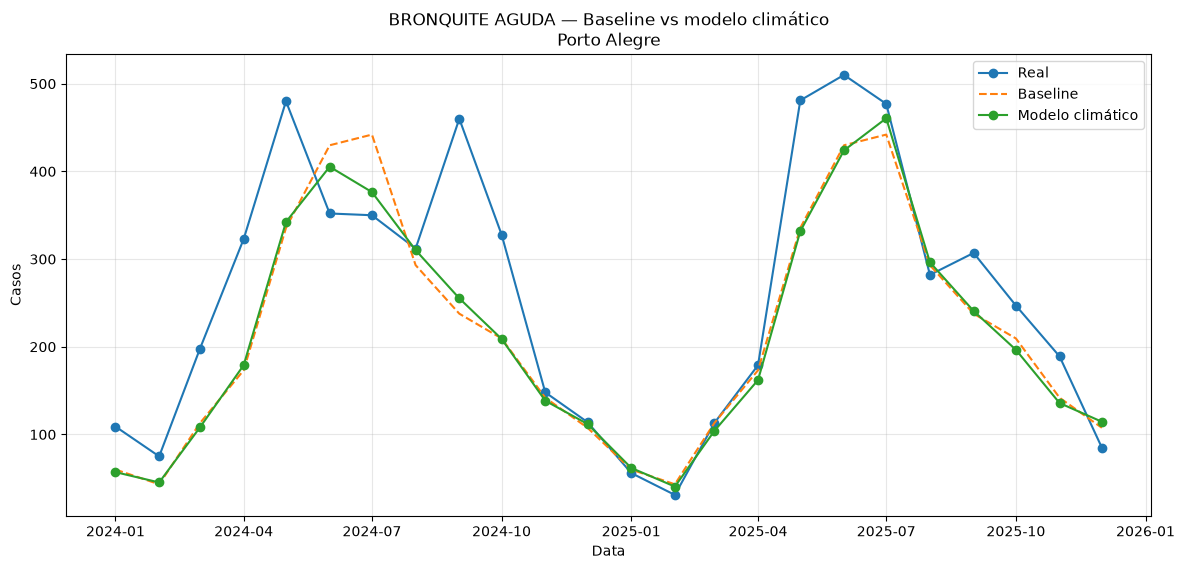

In [45]:
plot_df = final_test[
    final_test["municipality"] == "PORTO ALEGRE"
].copy()

plot_df["baseline"] = final_base.predict(plot_df)
plot_df["climate_model"] = final_nb.predict(plot_df)

plot_df = plot_df.sort_values("reference_date")

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["reference_date"],
    plot_df["cases"],
    marker="o",
    label="Real"
)

plt.plot(
    plot_df["reference_date"],
    plot_df["baseline"],
    linestyle="--",
    label="Baseline"
)

plt.plot(
    plot_df["reference_date"],
    plot_df["climate_model"],
    marker="o",
    label="Modelo climático"
)

plt.title(
    f"{DISEASE} — Baseline vs modelo climático\nPorto Alegre"
)

plt.xlabel("Data")
plt.ylabel("Casos")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [46]:

df_model = df.copy()

df_model["reference_date"] = pd.to_datetime(
    df_model["reference_date"].astype(str)
)

df_model = df_model.sort_values(
    ["municipality", "reference_date"]
)

train = df_model[
    df_model["reference_date"] < pd.Timestamp("2024-01-01")
].copy()

future = df_model[
    df_model["reference_date"] >= pd.Timestamp("2024-01-01")
].copy()

print(
    "Treino:",
    train["reference_date"].min(),
    "até",
    train["reference_date"].max()
)

print(
    "Teste:",
    future["reference_date"].min(),
    "até",
    future["reference_date"].max()
)

Treino: 2015-01-01 00:00:00 até 2023-12-01 00:00:00
Teste: 2024-01-01 00:00:00 até 2025-12-01 00:00:00


In [47]:
import statsmodels.formula.api as smf

DISEASE = "LEPTOSPIROSE"

features = [
    "precipitation_sum_mm_lag2",
    "temperature_avg_c_lag1",
    "relative_humidity_avg_pct"
]

columns_needed = (
    ["cases", "municipality", "month"]
    + features
)

train_model = (
    train[
        train["disease"] == DISEASE
    ]
    .dropna(subset=columns_needed)
    .copy()
)

future_model = (
    future[
        future["disease"] == DISEASE
    ]
    .dropna(subset=columns_needed)
    .copy()
)

# Evita problema do Int64Dtype com patsy
train_model["cases"] = train_model["cases"].astype(float)
train_model["municipality"] = train_model["municipality"].astype(str)
train_model["month"] = train_model["month"].astype(int)

future_model["cases"] = future_model["cases"].astype(float)
future_model["municipality"] = future_model["municipality"].astype(str)
future_model["month"] = future_model["month"].astype(int)

In [48]:
formula = """
cases ~
C(municipality) +
C(month) +
precipitation_sum_mm_lag2 +
temperature_avg_c_lag1 +
relative_humidity_avg_pct
"""

model_2023 = smf.negativebinomial(
    formula=formula,
    data=train_model
).fit(
    method="bfgs",
    maxiter=1000,
    disp=False
)

print("Convergiu:", model_2023.mle_retvals["converged"])

Convergiu: True


c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


In [50]:
train_cities = set(
    train_model["municipality"].unique()
)

future_cities = set(
    future_model["municipality"].unique()
)

unseen_cities = future_cities - train_cities

print("Municípios não vistos no treino:")
print(unseen_cities)

Municípios não vistos no treino:
{'SOLEDADE'}


In [51]:
future_model_seen = future_model[
    future_model["municipality"].isin(train_cities)
].copy()

print("Linhas antes:", len(future_model))
print("Linhas após remover municípios não vistos:", len(future_model_seen))

Linhas antes: 426
Linhas após remover municípios não vistos: 414


In [53]:
future_model_seen["prediction"] = (
    model_2023.predict(
        future_model_seen
    )
)

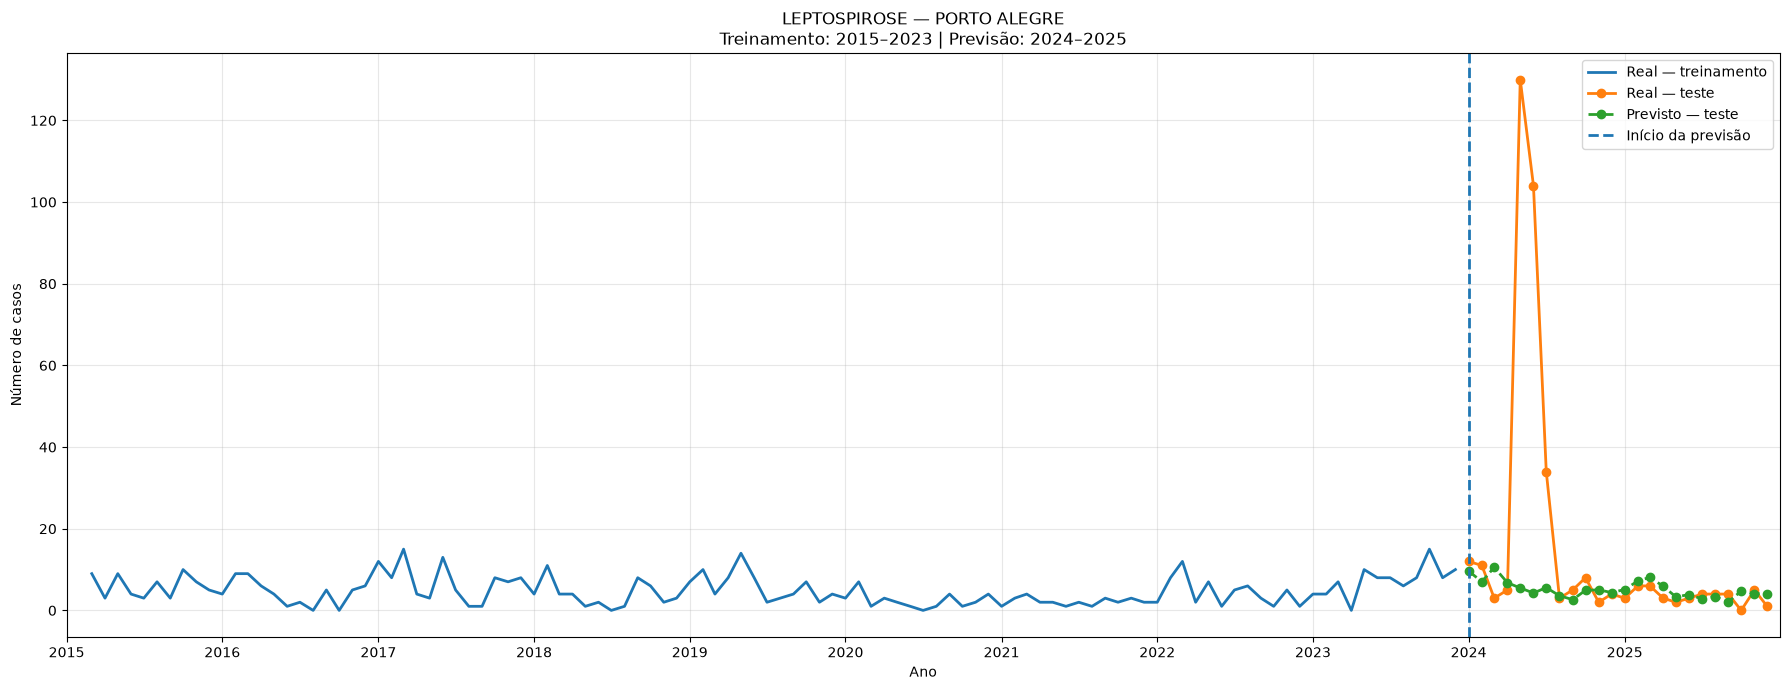

In [56]:
CITY = "PORTO ALEGRE"

# Dados históricos usados no treinamento
historical = (
    train_model[
        train_model["municipality"] == CITY
    ]
    .sort_values("reference_date")
    .copy()
)

# Dados futuros
forecast = (
    future_model_seen[
        future_model_seen["municipality"] == CITY
    ]
    .sort_values("reference_date")
    .copy()
)

# restringe explicitamente 2015-2025
historical = historical[
    historical["reference_date"].between(
        pd.Timestamp("2015-01-01"),
        pd.Timestamp("2023-12-31")
    )
]

forecast = forecast[
    forecast["reference_date"].between(
        pd.Timestamp("2024-01-01"),
        pd.Timestamp("2025-12-31")
    )
]

plt.figure(figsize=(18, 7))

# Real 2015-2023
plt.plot(
    historical["reference_date"],
    historical["cases"],
    linewidth=2,
    label="Real — treinamento"
)

# Real 2024-2025
plt.plot(
    forecast["reference_date"],
    forecast["cases"],
    linewidth=2,
    marker="o",
    label="Real — teste"
)

# Previsão 2024-2025
plt.plot(
    forecast["reference_date"],
    forecast["prediction"],
    linewidth=2,
    linestyle="--",
    marker="o",
    label="Previsto — teste"
)

# separação treino/teste
plt.axvline(
    pd.Timestamp("2024-01-01"),
    linestyle="--",
    linewidth=2,
    label="Início da previsão"
)

plt.title(
    f"{DISEASE} — {CITY}\n"
    "Treinamento: 2015–2023 | Previsão: 2024–2025"
)

plt.xlabel("Ano")
plt.ylabel("Número de casos")

plt.legend()
plt.grid(alpha=0.3)

plt.xlim(
    pd.Timestamp("2015-01-01"),
    pd.Timestamp("2025-12-31")
)

plt.tight_layout()
plt.show()